# COE 311K Final Project - Part 1
Pressley Welsh - pbw466
Mary Grayson Horton - mh63289

## Introduction and Model Selection

Mountain bike suspension after hitting a bump. 
Spring-Mass System.

## Parameter Research and Justification

Spring constant (k) from fox factory: 123000 N/m
Mass (m) of bike from fox factory: 13.15 kg
Mass (m) of rider from CDC: 90.2649 kg typical male mass
Damping coefficient (c) from Mountain Bike Rear Suspension Damping Analysis: 3,000 N*s/m 
Bike: Slash 9.8
Suspension: DHX2
Fox factory bike: https://www.trekbikes.com/us/en_US/bikes/mountain-bikes/trail-mountain-bikes/slash/slash-9-8/p/28516/
CDC: https://www.cdc.gov/nchs/fastats/body-measurements.htm
Mountain Bike Rear Suspension Damping Analysis: https://dean-rogers-portfolio.github.io/assets/doc/vibrations_report.pdf

## Numerical Methods Implementation

In [6]:
import numpy as np
import matplotlib.pyplot as plt


m = 103.4148
c = 3000
k = 123000

def f1(y1, y2):
    return -(c/m)*y2 - (k/m)*y1

def euler_forward(t0, tf, h, y1_0, y2_0):
    t_values = np.arange(t0, tf + h, h)
    y1_values = np.zeros(len(t_values))
    y2_values = np.zeros(len(t_values))
    
    y1_values[0] = y1_0
    y2_values[0] = y2_0
    
    for i in range(1, len(t_values)):
        t = t_values[i-1]
        y1 = y1_values[i-1]
        y2 = y2_values[i-1]
        
        y1_values[i] = y1 + h*y2
        y2_values[i] = y2 + h*f1(y1, y2)
        
    return t_values, y1_values, y2_values

In [7]:
def f2(t,y):
    y1 = y[0]
    y2 = y[1]
    
    dy1dt = y2
    dy2dt = -(c/m)*y2 - (k/m)*y1

    return np.array([dy1dt, dy2dt])

def runge_kutta_4(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros((len(t_values), 2))
    
    y_values[0] = y0
    
    for i in range(1, len(t_values)):
        t = t_values[i - 1]
        y = y_values[i - 1]
        k1 = h * f2(t, y)
        k2 = h * f2(t + h / 2, y + k1 / 2)
        k3 = h * f2(t + h / 2, y + k2 / 2)
        k4 = h * f2(t + h, y + k3)
        
        y_values[i] = y + (k1 + 2*k2 + 2*k3 + k4) / 6
    return t_values, y_values

We started with the second-order ODE: my"" + cy' + ky = 0. We turned this into a system of first-order ODEs of:
- y1 = y
- y2 = y'
- y1' = y2
- y2' = −(c/m)y2 − (k/m)y1

Explanation of method

## Solutions and Comparison

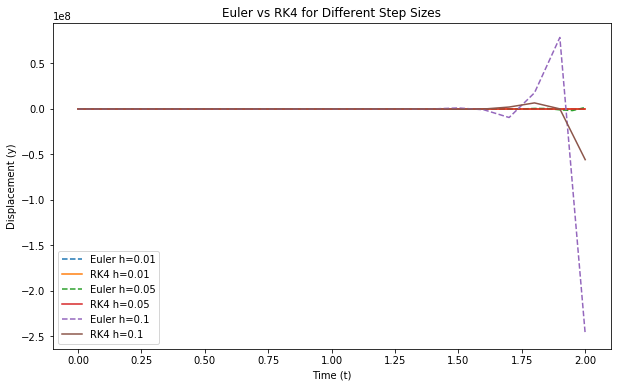

In [12]:
h_values = [0.01, 0.05, 0.1]

plt.figure(figsize=(10,6))

for h in h_values:
    t_euler, y_euler, _ = euler_forward(0, 2, h, 0.03, 0)
    plt.plot(t_euler, y_euler, '--', label=f'Euler h={h}')
    
    y0 = np.array([0.03, 0])
    t_rk4, y_rk4 = runge_kutta_4(f, y0, 0, 2, h)
    plt.plot(t_rk4, y_rk4[:,0], label=f'RK4 h={h}')

plt.xlabel("Time (t)")
plt.ylabel("Displacement (y)")
plt.title("Euler vs RK4 for Different Step Sizes")
plt.legend()
plt.show()

## Stability Analysis

## Conclusions 